In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [6]:
import os

# Dataset path
dataset_path = "/kaggle/input/datasets/jeremypoveda/fondo-del-ojo-normal-glaucoma-retinopatia/dataset"

# Train and test paths
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")

# Display paths
print("Dataset path:", dataset_path)
print("Train path:", train_path)
print("Test path:", test_path)

# Display classes
print("\nTrain classes:", os.listdir(train_path))
print("Test classes:", os.listdir(test_path))

Dataset path: /kaggle/input/datasets/jeremypoveda/fondo-del-ojo-normal-glaucoma-retinopatia/dataset
Train path: /kaggle/input/datasets/jeremypoveda/fondo-del-ojo-normal-glaucoma-retinopatia/dataset/train
Test path: /kaggle/input/datasets/jeremypoveda/fondo-del-ojo-normal-glaucoma-retinopatia/dataset/test

Train classes: ['glaucoma', 'normal']
Test classes: ['glaucoma', 'normal']


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

In [8]:
classes = ["glaucoma", "normal"]
extensions = (".jpg", ".jpeg", ".png", ".bmp")

def count_images(path):
    counts = {}

    for cls in classes:
        class_path = os.path.join(path, cls)

        counts[cls] = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(extensions)
        ])

    return counts


train_counts = count_images(train_path)
test_counts = count_images(test_path)

print("Training images:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\nTest images:")
for cls, count in test_counts.items():
    print(f"{cls}: {count}")

Training images:
glaucoma: 6950
normal: 10880

Test images:
glaucoma: 241
normal: 533


,Class,Train,Test
0,glaucoma,6950,241
1,normal,10880,533


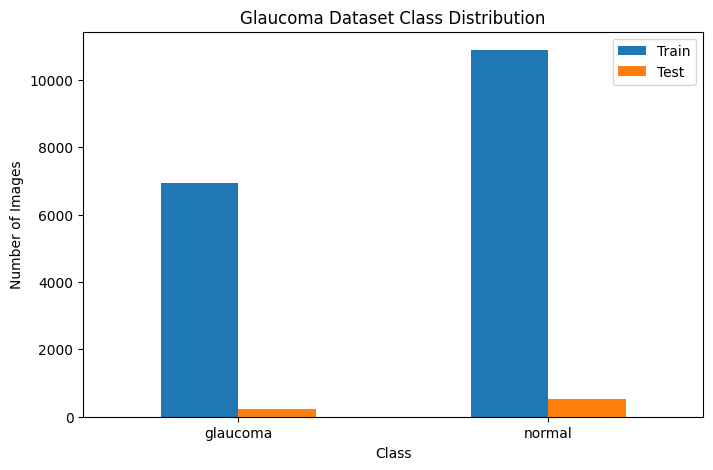

In [9]:
distribution = pd.DataFrame({
    "Class": classes,
    "Train": [train_counts[c] for c in classes],
    "Test": [test_counts[c] for c in classes]
})

display(distribution)

distribution.plot(
    x="Class",
    y=["Train", "Test"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Glaucoma Dataset Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

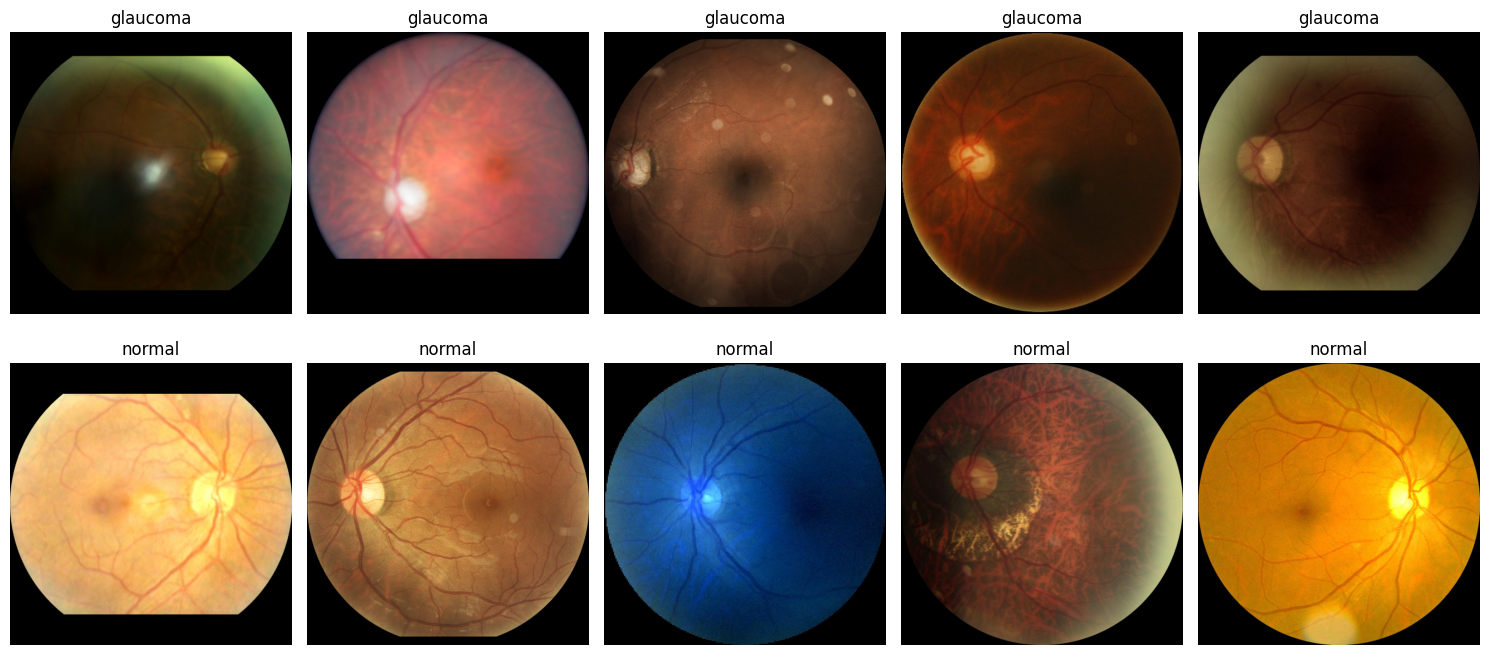

In [10]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 7)
)

for row, cls in enumerate(classes):

    class_path = os.path.join(train_path, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(extensions)
    ]

    for col in range(5):

        image_path = os.path.join(
            class_path,
            images[col]
        )

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(cls)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# Data Preprocessing

In [37]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 17830 files belonging to 2 classes.
Using 14264 files for training.
Found 17830 files belonging to 2 classes.
Using 3566 files for validation.
Found 774 files belonging to 2 classes.


In [39]:
print("Train class names:", train_ds.class_names)
print("Validation class names:", val_ds.class_names)

train_labels = []
val_labels = []

for _, labels in train_ds:
    train_labels.extend(labels.numpy())

for _, labels in val_ds:
    val_labels.extend(labels.numpy())

import numpy as np

print("\nTraining distribution:")
print(np.bincount(train_labels, minlength=2))

print("\nValidation distribution:")
print(np.bincount(val_labels, minlength=2))

Train class names: ['glaucoma', 'normal']
Validation class names: ['glaucoma', 'normal']

Training distribution:
[5599 8665]

Validation distribution:
[1351 2215]


In [40]:
class_names = train_ds.class_names

In [41]:
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [42]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [43]:
images, labels = next(iter(train_ds))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)
print("Pixel range:",
      float(tf.reduce_min(images)),
      "to",
      float(tf.reduce_max(images)))

Image shape: (32, 224, 224, 3)
Label shape: (32,)
Pixel range: 0.0 to 1.0


# Baseline CNN

In [44]:
baseline_cnn = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    # Binary classification
    tf.keras.layers.Dense(1, activation="sigmoid")
])

baseline_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [46]:
history = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[
        early_stopping
    ]
)

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 35s 71ms/step - accuracy: 0.7358 - loss: 0.5388 - val_accuracy: 0.8012 - val_loss: 0.4486
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.7984 - loss: 0.4507 - val_accuracy: 0.8029 - val_loss: 0.4131
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.8127 - loss: 0.4206 - val_accuracy: 0.8460 - val_loss: 0.3994
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8293 - loss: 0.3974 - val_accuracy: 0.8500 - val_loss: 0.3835
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8320 - loss: 0.3894 - val_accuracy: 0.8256 - val_loss: 0.3980
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.8376 - loss: 0.3750 - val_accuracy: 0.8497 - val_loss: 0.3497
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8406 - loss: 0.3616 - val_accuracy: 0.8474 - val_loss: 0.3587
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8484 - loss: 0.3535 - 

## Loss Plot

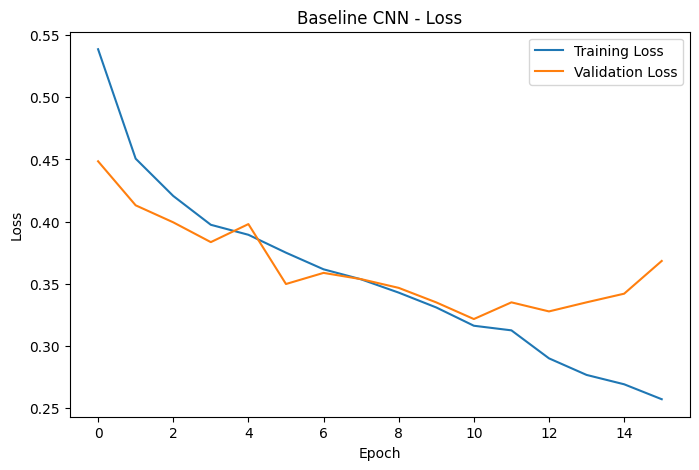

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN - Loss")
plt.legend()
plt.show()

## Accuracy Plot

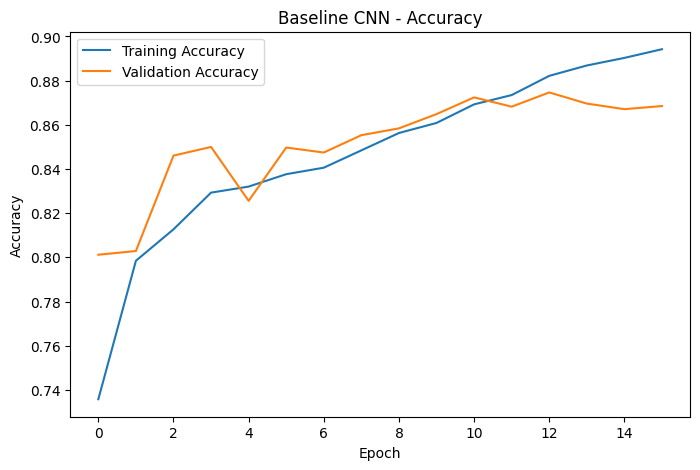

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN - Accuracy")
plt.legend()
plt.show()

## Evaluation

In [53]:
y_test_true = []
y_test_prob = []

for images, labels in test_ds:

    probabilities = baseline_cnn.predict(
        images,
        verbose=0
    ).ravel()

    y_test_true.extend(labels.numpy())
    y_test_prob.extend(probabilities)

y_test_true = np.array(y_test_true)
y_test_prob = np.array(y_test_prob)

# 0 = glaucoma
# 1 = normal
y_test_pred = (y_test_prob >= 0.5).astype(int)

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    glaucoma       0.73      0.23      0.35       241
      normal       0.73      0.96      0.83       533

    accuracy                           0.73       774
   macro avg       0.73      0.60      0.59       774
weighted avg       0.73      0.73      0.68       774



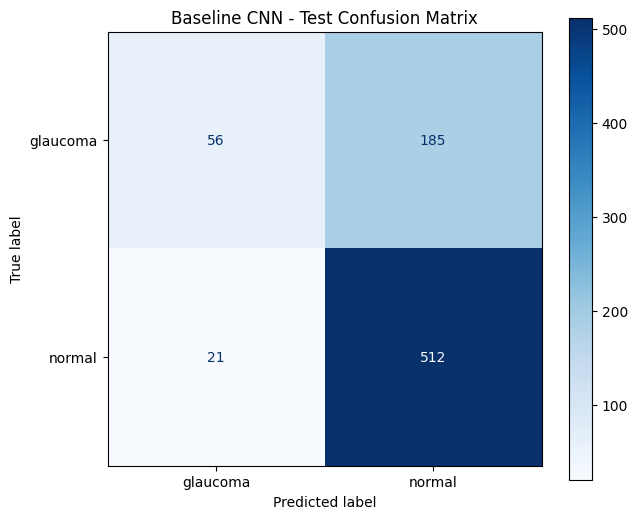

In [56]:
cm = confusion_matrix(
    y_test_true,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Baseline CNN - Test Confusion Matrix")
plt.show()

In [55]:
accuracy = accuracy_score(y_test_true, y_test_pred)
precision = precision_score(y_test_true, y_test_pred, average="binary", pos_label=0)
glaucoma_recall = recall_score(y_test_true, y_test_pred, average="binary", pos_label=0)
glaucoma_f1 = f1_score(y_test_true, y_test_pred, average="binary", pos_label=0)
macro_precision = precision_score(y_test_true, y_test_pred, average="macro")
macro_recall = recall_score(y_test_true, y_test_pred, average="macro")
macro_f1 = f1_score(y_test_true, y_test_pred, average="macro")
roc_auc = roc_auc_score(y_test_true, y_test_prob)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Glaucoma Precision : {precision:.4f}")
print(f"Glaucoma Recall    : {glaucoma_recall:.4f}")
print(f"Glaucoma F1        : {glaucoma_f1:.4f}")
print(f"Macro Precision    : {macro_precision:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1           : {macro_f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")

Accuracy           : 0.7339
Glaucoma Precision : 0.7273
Glaucoma Recall    : 0.2324
Glaucoma F1        : 0.3522
Macro Precision    : 0.7309
Macro Recall       : 0.5965
Macro F1           : 0.5924
ROC-AUC            : 0.6864


# CNN With Class Weights

In [59]:
y_train = np.array([0] * 5599 + [1] * 8665)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights:")
print(f"Glaucoma (0): {class_weights[0]:.4f}")
print(f"Normal (1): {class_weights[1]:.4f}")

Class weights:
Glaucoma (0): 1.2738
Normal (1): 0.8231


In [61]:
class_weighted_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

class_weighted_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [62]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [64]:
history_cw = class_weighted_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.6854 - loss: 0.5805 - val_accuracy: 0.7737 - val_loss: 0.5109
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.7690 - loss: 0.4922 - val_accuracy: 0.7824 - val_loss: 0.4534
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7968 - loss: 0.4441 - val_accuracy: 0.8043 - val_loss: 0.4187
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8200 - loss: 0.4217 - val_accuracy: 0.8486 - val_loss: 0.3798
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.8376 - loss: 0.3930 - val_accuracy: 0.8550 - val_loss: 0.3639
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8505 - loss: 0.3747 - val_accuracy: 0.8449 - val_loss: 0.3674
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.8504 - loss: 0.3668 - val_accuracy: 0.8410 - val_loss: 0.3825
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8613 - loss: 0.3524 - 

## Loss Plot

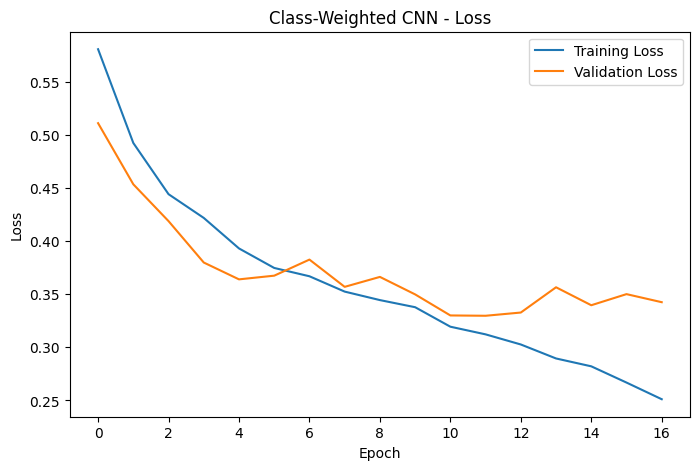

In [65]:
plt.figure(figsize=(8, 5))
plt.plot(history_cw.history["loss"], label="Training Loss")
plt.plot(history_cw.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Class-Weighted CNN - Loss")
plt.legend()
plt.show()

## Accuracy Plot

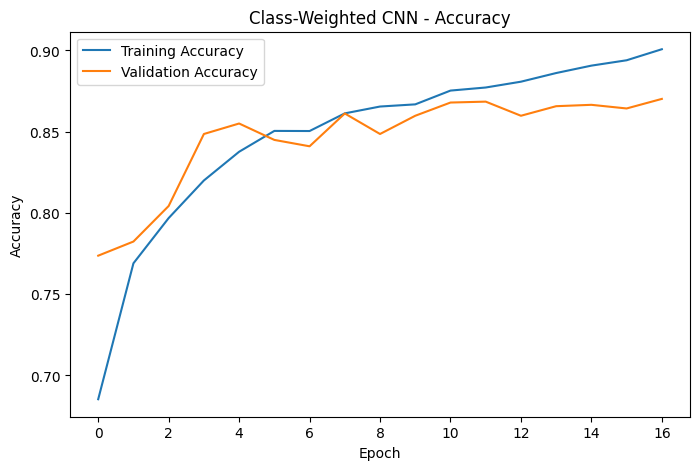

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(history_cw.history["accuracy"], label="Training Accuracy")
plt.plot(history_cw.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Class-Weighted CNN - Accuracy")
plt.legend()
plt.show()

## Evaluation

In [67]:
y_test_true_cw = []
y_test_prob_cw = []

for images, labels in test_ds:
    probabilities = class_weighted_cnn.predict(images, verbose=0).ravel()
    y_test_true_cw.extend(labels.numpy())
    y_test_prob_cw.extend(probabilities)

y_test_true_cw = np.array(y_test_true_cw)
y_test_prob_cw = np.array(y_test_prob_cw)

y_test_pred_cw = (y_test_prob_cw >= 0.5).astype(int)

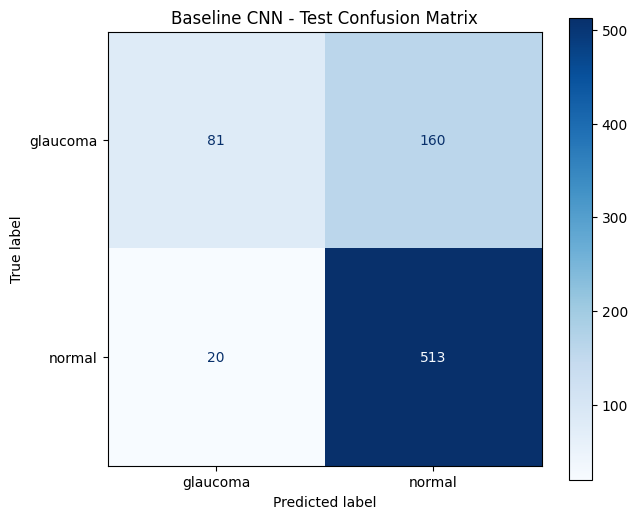

In [68]:
cm = confusion_matrix(
    y_test_true_cw,
    y_test_pred_cw
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Baseline CNN - Test Confusion Matrix")
plt.show()

In [69]:
accuracy_cw = accuracy_score(y_test_true_cw, y_test_pred_cw)
precision_cw = precision_score(y_test_true_cw, y_test_pred_cw, pos_label=0)
glaucoma_recall_cw = recall_score(y_test_true_cw, y_test_pred_cw, pos_label=0)
glaucoma_f1_cw = f1_score(y_test_true_cw, y_test_pred_cw, pos_label=0)
macro_precision_cw = precision_score(y_test_true_cw, y_test_pred_cw, average="macro")
macro_recall_cw = recall_score(y_test_true_cw, y_test_pred_cw, average="macro")
macro_f1_cw = f1_score(y_test_true_cw, y_test_pred_cw, average="macro")
roc_auc_cw = roc_auc_score(y_test_true_cw, y_test_prob_cw)

print("CLASS-WEIGHTED CNN — TEST SET")
print("-" * 40)
print(f"Accuracy           : {accuracy_cw:.4f}")
print(f"Glaucoma Precision : {precision_cw:.4f}")
print(f"Glaucoma Recall    : {glaucoma_recall_cw:.4f}")
print(f"Glaucoma F1        : {glaucoma_f1_cw:.4f}")
print(f"Macro Precision    : {macro_precision_cw:.4f}")
print(f"Macro Recall       : {macro_recall_cw:.4f}")
print(f"Macro F1           : {macro_f1_cw:.4f}")
print(f"ROC-AUC            : {roc_auc_cw:.4f}")

CLASS-WEIGHTED CNN — TEST SET
----------------------------------------
Accuracy           : 0.7674
Glaucoma Precision : 0.8020
Glaucoma Recall    : 0.3361
Glaucoma F1        : 0.4737
Macro Precision    : 0.7821
Macro Recall       : 0.6493
Macro F1           : 0.6622
ROC-AUC            : 0.7468


# Class-weighted CNN With Augmentation

In [70]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

In [72]:
aug_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    
    tf.keras.layers.Dense(1, activation="sigmoid")
])

aug_cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
aug_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True)

In [75]:
history_aug = aug_cnn.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=50, 
    class_weight=class_weights, 
    callbacks=[early_stopping])

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 40s 76ms/step - accuracy: 0.6265 - loss: 0.6204 - val_accuracy: 0.7193 - val_loss: 0.5664
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.6765 - loss: 0.5882 - val_accuracy: 0.6896 - val_loss: 0.5627
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.6930 - loss: 0.5757 - val_accuracy: 0.7114 - val_loss: 0.5480
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.7082 - loss: 0.5649 - val_accuracy: 0.7431 - val_loss: 0.5341
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.7140 - loss: 0.5563 - val_accuracy: 0.7594 - val_loss: 0.5123
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7269 - loss: 0.5440 - val_accuracy: 0.7431 - val_loss: 0.4953
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7358 - loss: 0.5291 - val_accuracy: 0.7428 - val_loss: 0.5077
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 70ms/step - accuracy: 0.7416 - loss: 0.5232 - 

## Loss Plot

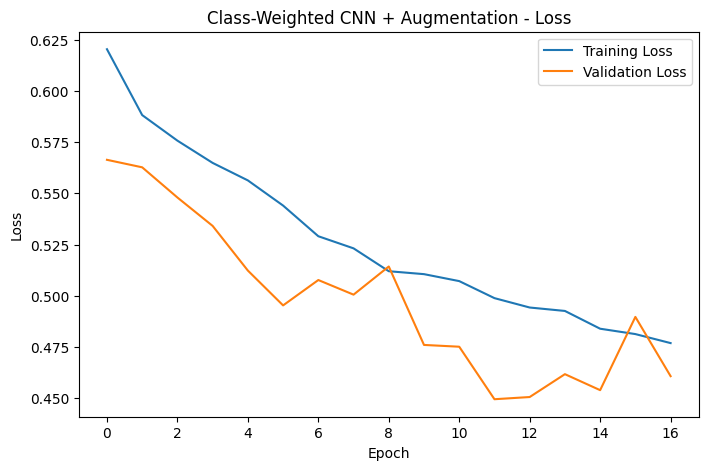

In [76]:
plt.figure(figsize=(8,5))
plt.plot(history_aug.history["loss"], label="Training Loss")
plt.plot(history_aug.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Class-Weighted CNN + Augmentation - Loss")
plt.legend()
plt.show()

## Accuracy Plot

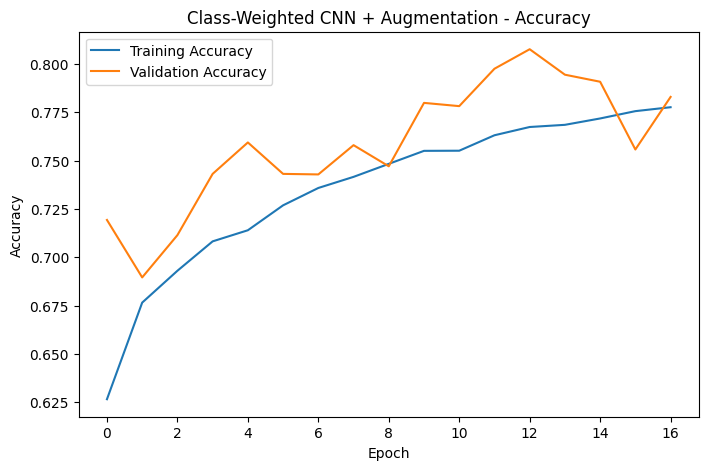

In [77]:
plt.figure(figsize=(8,5))
plt.plot(history_aug.history["accuracy"], label="Training Accuracy")
plt.plot(history_aug.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Class-Weighted CNN + Augmentation - Accuracy")
plt.legend()
plt.show()

## Evaluation

In [78]:
y_test_true_aug = []
y_test_prob_aug = []

for images, labels in test_ds:
    probabilities = aug_cnn.predict(images, verbose=0).ravel()
    y_test_true_aug.extend(labels.numpy())
    y_test_prob_aug.extend(probabilities)

y_test_true_aug = np.array(y_test_true_aug)
y_test_prob_aug = np.array(y_test_prob_aug)
y_test_pred_aug = (y_test_prob_aug >= 0.5).astype(int)

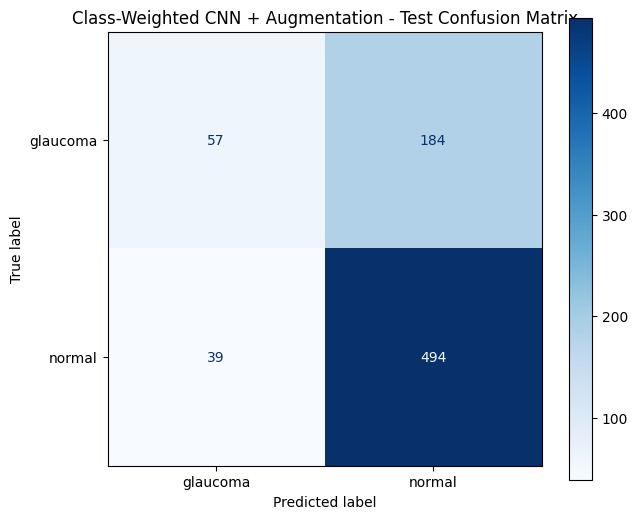

In [81]:
cm = confusion_matrix(
    y_test_true_aug,
    y_test_pred_aug
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Class-Weighted CNN + Augmentation - Test Confusion Matrix")
plt.show()

In [80]:
accuracy_aug = accuracy_score(y_test_true_aug, y_test_pred_aug)
precision_aug = precision_score(y_test_true_aug, y_test_pred_aug, pos_label=0)
glaucoma_recall_aug = recall_score(y_test_true_aug, y_test_pred_aug, pos_label=0)
glaucoma_f1_aug = f1_score(y_test_true_aug, y_test_pred_aug, pos_label=0)
macro_precision_aug = precision_score(y_test_true_aug, y_test_pred_aug, average="macro")
macro_recall_aug = recall_score(y_test_true_aug, y_test_pred_aug, average="macro")
macro_f1_aug = f1_score(y_test_true_aug, y_test_pred_aug, average="macro")
roc_auc_aug = roc_auc_score(y_test_true_aug, y_test_prob_aug)

print("CLASS-WEIGHTED CNN + AUGMENTATION — TEST SET")
print("-" * 50)
print(f"Accuracy           : {accuracy_aug:.4f}")
print(f"Glaucoma Precision : {precision_aug:.4f}")
print(f"Glaucoma Recall    : {glaucoma_recall_aug:.4f}")
print(f"Glaucoma F1        : {glaucoma_f1_aug:.4f}")
print(f"Macro Precision    : {macro_precision_aug:.4f}")
print(f"Macro Recall       : {macro_recall_aug:.4f}")
print(f"Macro F1           : {macro_f1_aug:.4f}")
print(f"ROC-AUC            : {roc_auc_aug:.4f}")

CLASS-WEIGHTED CNN + AUGMENTATION — TEST SET
--------------------------------------------------
Accuracy           : 0.7119
Glaucoma Precision : 0.5938
Glaucoma Recall    : 0.2365
Glaucoma F1        : 0.3383
Macro Precision    : 0.6612
Macro Recall       : 0.5817
Macro F1           : 0.5771
ROC-AUC            : 0.6575


# Transfer Learning With EfficientNet

In [89]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

classes = ["glaucoma", "normal"]
extensions = (".jpg", ".jpeg", ".png", ".bmp")

image_paths = []
labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    for file in os.listdir(folder):
        if file.lower().endswith(extensions):
            image_paths.append(os.path.join(folder, file))
            labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    stratify=labels,
    random_state=SEED
)

print("Train:", np.bincount(y_train))
print("Validation:", np.bincount(y_val))

Train: [5560 8704]
Validation: [1390 2176]


In [90]:
test_paths = []
test_labels = []

for label, cls in enumerate(classes):
    folder = os.path.join(test_path, cls)
    for file in os.listdir(folder):
        if file.lower().endswith(extensions):
            test_paths.append(os.path.join(folder, file))
            test_labels.append(label)

test_paths = np.array(test_paths)
test_labels = np.array(test_labels)

print("Test:", np.bincount(test_labels))

Test: [241 533]


In [92]:
def preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

In [93]:
train_ds_eff = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_eff = tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_eff = tf.data.Dataset.from_tensor_slices((test_paths, test_labels)).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [94]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

efficientnet_cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

efficientnet_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

efficientnet_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [95]:
early_stopping_eff = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True)

In [96]:
history_eff = efficientnet_cnn.fit(
    train_ds_eff, 
    validation_data=val_ds_eff, 
    epochs=50, 
    class_weight=class_weights, 
    callbacks=[early_stopping_eff])

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.7524 - loss: 0.5001 - val_accuracy: 0.8155 - val_loss: 0.4045
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.7844 - loss: 0.4469 - val_accuracy: 0.8127 - val_loss: 0.4056
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.7942 - loss: 0.4349 - val_accuracy: 0.8180 - val_loss: 0.3819
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8018 - loss: 0.4178 - val_accuracy: 0.8312 - val_loss: 0.3848
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.8067 - loss: 0.4095 - val_accuracy: 0.8404 - val_loss: 0.3635
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8092 - loss: 0.4070 - val_accuracy: 0.8458 - val_loss: 0.3643
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 68ms/step - accuracy: 0.8146 - loss: 0.4006 - val_accuracy: 0.8463 - val_loss: 0.3452
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.8163 - loss: 0.3930 -

## Loss Plot

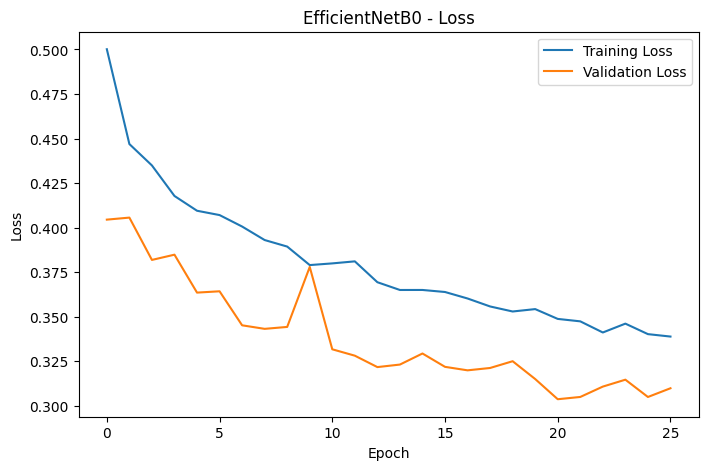

In [101]:
plt.figure(figsize=(8,5))
plt.plot(history_eff.history["loss"], label="Training Loss")
plt.plot(history_eff.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 - Loss")
plt.legend()
plt.show()

## Accuracy Plot

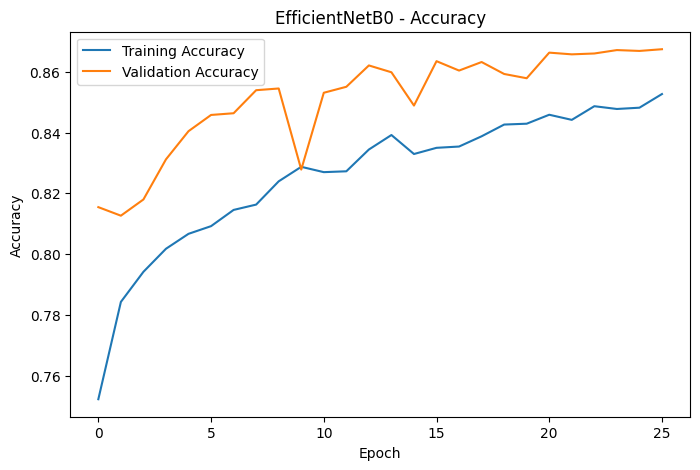

In [102]:
plt.figure(figsize=(8,5))
plt.plot(history_eff.history["accuracy"], label="Training Accuracy")
plt.plot(history_eff.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 - Accuracy")
plt.legend()
plt.show()

## Evaluation

In [97]:
y_test_true_eff = []
y_test_prob_eff = []

for images, labels in test_ds_eff:
    probabilities = efficientnet_cnn.predict(images, verbose=0).ravel()
    y_test_true_eff.extend(labels.numpy())
    y_test_prob_eff.extend(probabilities)

y_test_true_eff = np.array(y_test_true_eff)
y_test_prob_eff = np.array(y_test_prob_eff)
y_test_pred_eff = (y_test_prob_eff >= 0.5).astype(int)

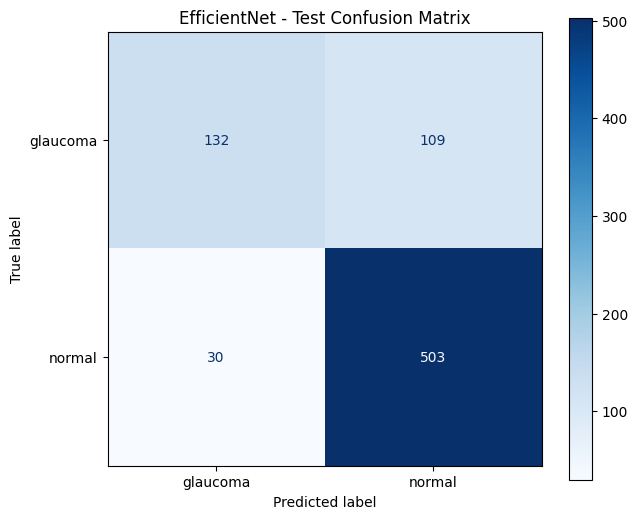

In [99]:
cm = confusion_matrix(
    y_test_true_eff,
    y_test_pred_eff
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("EfficientNet - Test Confusion Matrix")
plt.show()

In [100]:
accuracy_eff = accuracy_score(y_test_true_eff, y_test_pred_eff)
precision_eff = precision_score(y_test_true_eff, y_test_pred_eff, pos_label=0)
glaucoma_recall_eff = recall_score(y_test_true_eff, y_test_pred_eff, pos_label=0)
glaucoma_f1_eff = f1_score(y_test_true_eff, y_test_pred_eff, pos_label=0)
macro_precision_eff = precision_score(y_test_true_eff, y_test_pred_eff, average="macro")
macro_recall_eff = recall_score(y_test_true_eff, y_test_pred_eff, average="macro")
macro_f1_eff = f1_score(y_test_true_eff, y_test_pred_eff, average="macro")
roc_auc_eff = roc_auc_score(y_test_true_eff, y_test_prob_eff)

print("EFFICIENTNETB0 — TEST SET")
print("-" * 40)
print(f"Accuracy           : {accuracy_eff:.4f}")
print(f"Glaucoma Precision : {precision_eff:.4f}")
print(f"Glaucoma Recall    : {glaucoma_recall_eff:.4f}")
print(f"Glaucoma F1        : {glaucoma_f1_eff:.4f}")
print(f"Macro Precision    : {macro_precision_eff:.4f}")
print(f"Macro Recall       : {macro_recall_eff:.4f}")
print(f"Macro F1           : {macro_f1_eff:.4f}")
print(f"ROC-AUC            : {roc_auc_eff:.4f}")

EFFICIENTNETB0 — TEST SET
----------------------------------------
Accuracy           : 0.8204
Glaucoma Precision : 0.8148
Glaucoma Recall    : 0.5477
Glaucoma F1        : 0.6551
Macro Precision    : 0.8184
Macro Recall       : 0.7457
Macro F1           : 0.7668
ROC-AUC            : 0.8632


# Fine-tuned Efficient Net

In [110]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Trainable layers:", sum(layer.trainable for layer in base_model.layers))

Trainable layers: 23


In [111]:
fine_tuned_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [112]:
fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True)

In [113]:
history_ft = fine_tuned_model.fit(
    train_ds_eff, 
    validation_data=val_ds_eff, 
    epochs=50, 
    class_weight=class_weights, 
    callbacks=[early_stopping_ft])

Epoch 1/50


2026-08-12 15:25:40.960248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 15:25:41.170009: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 15:25:41.612375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 15:25:41.818630: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


445/446 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6120 - loss: 0.6771

2026-08-12 15:26:21.561645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 15:26:21.774633: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 15:26:22.181357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 15:26:22.394727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


446/446 ━━━━━━━━━━━━━━━━━━━━ 84s 133ms/step - accuracy: 0.6497 - loss: 0.6306 - val_accuracy: 0.7347 - val_loss: 0.5246
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7408 - loss: 0.5211 - val_accuracy: 0.7740 - val_loss: 0.4630
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.7644 - loss: 0.4820 - val_accuracy: 0.8003 - val_loss: 0.4252
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7831 - loss: 0.4543 - val_accuracy: 0.8068 - val_loss: 0.4164
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.7945 - loss: 0.4350 - val_accuracy: 0.8124 - val_loss: 0.4036
Epoch 6/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - accuracy: 0.8012 - loss: 0.4259 - val_accuracy: 0.8107 - val_loss: 0.4061
Epoch 7/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.8087 - loss: 0.4080 - val_accuracy: 0.8225 - val_loss: 0.3894
Epoch 8/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.8180 - loss: 0.3933 - val_accura

## Loss Plot

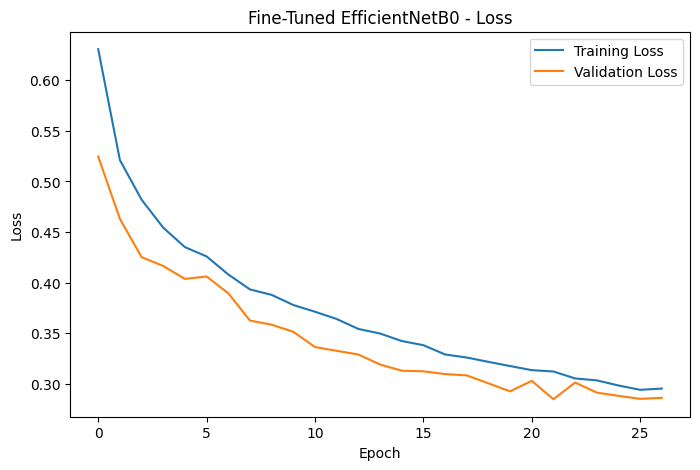

In [114]:
plt.figure(figsize=(8,5))
plt.plot(history_ft.history["loss"], label="Training Loss")
plt.plot(history_ft.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Fine-Tuned EfficientNetB0 - Loss")
plt.legend()
plt.show()

## Accuracy Plot

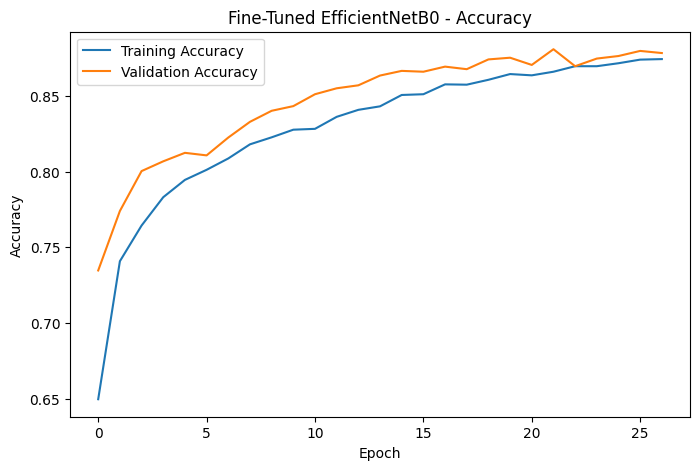

In [115]:
plt.figure(figsize=(8,5))
plt.plot(history_ft.history["accuracy"], label="Training Accuracy")
plt.plot(history_ft.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuned EfficientNetB0 - Accuracy")
plt.legend()
plt.show()

## Evaluation

In [116]:
y_test_true_ft = []
y_test_prob_ft = []

for images, labels in test_ds_eff:
    probabilities = fine_tuned_model.predict(images, verbose=0).ravel()
    y_test_true_ft.extend(labels.numpy())
    y_test_prob_ft.extend(probabilities)

y_test_true_ft = np.array(y_test_true_ft)
y_test_prob_ft = np.array(y_test_prob_ft)
y_test_pred_ft = (y_test_prob_ft >= 0.5).astype(int)

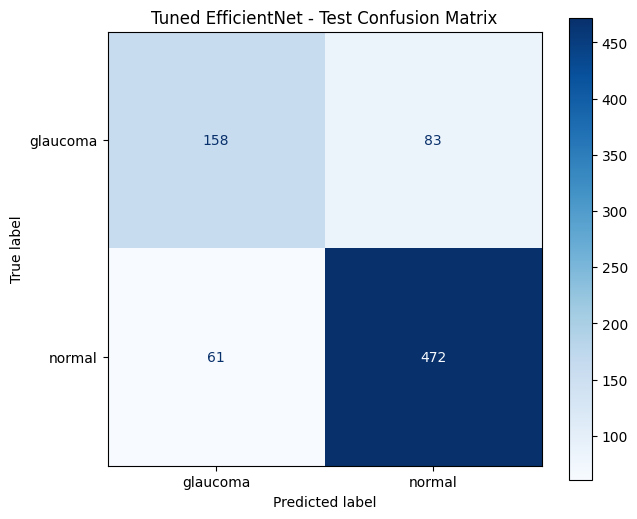

In [117]:
cm = confusion_matrix(
    y_test_true_ft,
    y_test_pred_ft
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues"
)

plt.title("Tuned EfficientNet - Test Confusion Matrix")
plt.show()

In [118]:
accuracy_ft = accuracy_score(y_test_true_ft, y_test_pred_ft)
precision_ft = precision_score(y_test_true_ft, y_test_pred_ft, pos_label=0)
glaucoma_recall_ft = recall_score(y_test_true_ft, y_test_pred_ft, pos_label=0)
glaucoma_f1_ft = f1_score(y_test_true_ft, y_test_pred_ft, pos_label=0)
macro_precision_ft = precision_score(y_test_true_ft, y_test_pred_ft, average="macro")
macro_recall_ft = recall_score(y_test_true_ft, y_test_pred_ft, average="macro")
macro_f1_ft = f1_score(y_test_true_ft, y_test_pred_ft, average="macro")
roc_auc_ft = roc_auc_score(y_test_true_ft, y_test_prob_ft)

print("FINE-TUNED EFFICIENTNETB0 — TEST SET")
print("-" * 45)
print(f"Accuracy           : {accuracy_ft:.4f}")
print(f"Glaucoma Precision : {precision_ft:.4f}")
print(f"Glaucoma Recall    : {glaucoma_recall_ft:.4f}")
print(f"Glaucoma F1        : {glaucoma_f1_ft:.4f}")
print(f"Macro Precision    : {macro_precision_ft:.4f}")
print(f"Macro Recall       : {macro_recall_ft:.4f}")
print(f"Macro F1           : {macro_f1_ft:.4f}")
print(f"ROC-AUC            : {roc_auc_ft:.4f}")

FINE-TUNED EFFICIENTNETB0 — TEST SET
---------------------------------------------
Accuracy           : 0.8140
Glaucoma Precision : 0.7215
Glaucoma Recall    : 0.6556
Glaucoma F1        : 0.6870
Macro Precision    : 0.7860
Macro Recall       : 0.7706
Macro F1           : 0.7773
ROC-AUC            : 0.8538


# Threshold Tuning

In [119]:
y_val_true_ft = []
y_val_prob_ft = []

for images, labels in val_ds_eff:
    probabilities = fine_tuned_model.predict(images, verbose=0).ravel()
    y_val_true_ft.extend(labels.numpy())
    y_val_prob_ft.extend(probabilities)

y_val_true_ft = np.array(y_val_true_ft)
y_val_prob_ft = np.array(y_val_prob_ft)

In [120]:
thresholds = np.arange(0.20, 0.81, 0.05)

results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob_ft >= threshold).astype(int)
    
    precision = precision_score(y_val_true_ft, y_val_pred, pos_label=0, zero_division=0)
    recall = recall_score(y_val_true_ft, y_val_pred, pos_label=0, zero_division=0)
    f1 = f1_score(y_val_true_ft, y_val_pred, pos_label=0, zero_division=0)
    
    results.append([threshold, precision, recall, f1])

results = np.array(results)

print("Threshold | Glaucoma Precision | Glaucoma Recall | Glaucoma F1")

for row in results:
    print(f"{row[0]:.2f}      | {row[1]:.4f}              | {row[2]:.4f}          | {row[3]:.4f}")

Threshold | Glaucoma Precision | Glaucoma Recall | Glaucoma F1
0.20      | 0.9481              | 0.6568          | 0.7760
0.25      | 0.9307              | 0.6957          | 0.7962
0.30      | 0.9199              | 0.7266          | 0.8119
0.35      | 0.9038              | 0.7504          | 0.8200
0.40      | 0.8926              | 0.7712          | 0.8275
0.45      | 0.8778              | 0.7957          | 0.8347
0.50      | 0.8642              | 0.8237          | 0.8435
0.55      | 0.8394              | 0.8496          | 0.8445
0.60      | 0.8127              | 0.8741          | 0.8423
0.65      | 0.7837              | 0.8914          | 0.8341
0.70      | 0.7500              | 0.9129          | 0.8235
0.75      | 0.7215              | 0.9338          | 0.8140
0.80      | 0.6784              | 0.9561          | 0.7937


In [122]:
best_threshold = 0.55
y_test_pred_ft_tuned = (y_test_prob_ft >= best_threshold).astype(int)

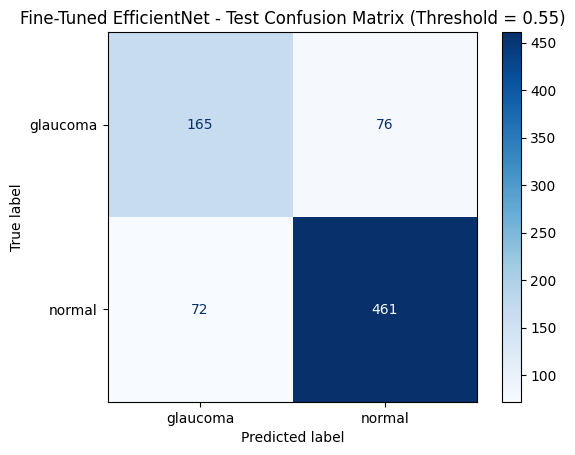

In [124]:
cm_ft_tuned = confusion_matrix(y_test_true_ft, y_test_pred_ft_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ft_tuned, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Fine-Tuned EfficientNet - Test Confusion Matrix (Threshold = 0.55)")
plt.show()

In [123]:
accuracy_ft_tuned = accuracy_score(y_test_true_ft, y_test_pred_ft_tuned)
precision_ft_tuned = precision_score(y_test_true_ft, y_test_pred_ft_tuned, pos_label=0, zero_division=0)
glaucoma_recall_ft_tuned = recall_score(y_test_true_ft, y_test_pred_ft_tuned, pos_label=0, zero_division=0)
glaucoma_f1_ft_tuned = f1_score(y_test_true_ft, y_test_pred_ft_tuned, pos_label=0, zero_division=0)
macro_precision_ft_tuned = precision_score(y_test_true_ft, y_test_pred_ft_tuned, average="macro", zero_division=0)
macro_recall_ft_tuned = recall_score(y_test_true_ft, y_test_pred_ft_tuned, average="macro", zero_division=0)
macro_f1_ft_tuned = f1_score(y_test_true_ft, y_test_pred_ft_tuned, average="macro", zero_division=0)
roc_auc_ft_tuned = roc_auc_score(y_test_true_ft, y_test_prob_ft)

print("FINE-TUNED EFFICIENTNET — THRESHOLD 0.55 — TEST SET")
print("-" * 55)
print(f"Threshold          : {best_threshold:.2f}")
print(f"Accuracy           : {accuracy_ft_tuned:.4f}")
print(f"Glaucoma Precision : {precision_ft_tuned:.4f}")
print(f"Glaucoma Recall    : {glaucoma_recall_ft_tuned:.4f}")
print(f"Glaucoma F1        : {glaucoma_f1_ft_tuned:.4f}")
print(f"Macro Precision    : {macro_precision_ft_tuned:.4f}")
print(f"Macro Recall       : {macro_recall_ft_tuned:.4f}")
print(f"Macro F1           : {macro_f1_ft_tuned:.4f}")
print(f"ROC-AUC            : {roc_auc_ft_tuned:.4f}")

FINE-TUNED EFFICIENTNET — THRESHOLD 0.55 — TEST SET
-------------------------------------------------------
Threshold          : 0.55
Accuracy           : 0.8088
Glaucoma Precision : 0.6962
Glaucoma Recall    : 0.6846
Glaucoma F1        : 0.6904
Macro Precision    : 0.7773
Macro Recall       : 0.7748
Macro F1           : 0.7760
ROC-AUC            : 0.8538
